<a href="https://colab.research.google.com/github/Nskaya7/Sales-Forecasting-with-Time-Series-Analysis/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting with Time Series Analysis
Forecasting retail sales using ARIMA and Facebook Prophet on the Rossmann Store Sales dataset.

In [1]:
!pip install prophet -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset
Using the Rossmann Store Sales dataset from Kaggle.

In [3]:
df = pd.read_csv('train.csv', low_memory=False)
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True, errors='coerce')
df = df.dropna(subset=['Date'])

store_df = df[(df['Store'] == 1) & (df['Open'] == 1)].copy()
store_df = store_df.sort_values('Date')
store_df = store_df.set_index('Date')
store_df.index = pd.DatetimeIndex(store_df.index)

print(type(store_df.index))
print(store_df.shape)
print(store_df.head())

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
(588, 8)
            Store  DayOfWeek  Sales  Customers  Open  Promo StateHoliday  \
Date                                                                       
2013-08-22      1          4   3703      498.0   1.0    0.0            0   
2013-08-23      1          5   3493      445.0   1.0    0.0            0   
2013-08-24      1          6   4752      601.0   1.0    0.0            0   
2013-08-26      1          1   5482      613.0   1.0    1.0            0   
2013-08-27      1          2   5156      556.0   1.0    1.0            0   

            SchoolHoliday  
Date                       
2013-08-22            0.0  
2013-08-23            0.0  
2013-08-24            0.0  
2013-08-26            0.0  
2013-08-27            0.0  


## 2. Exploratory Data Analysis

Store 1 records: 588


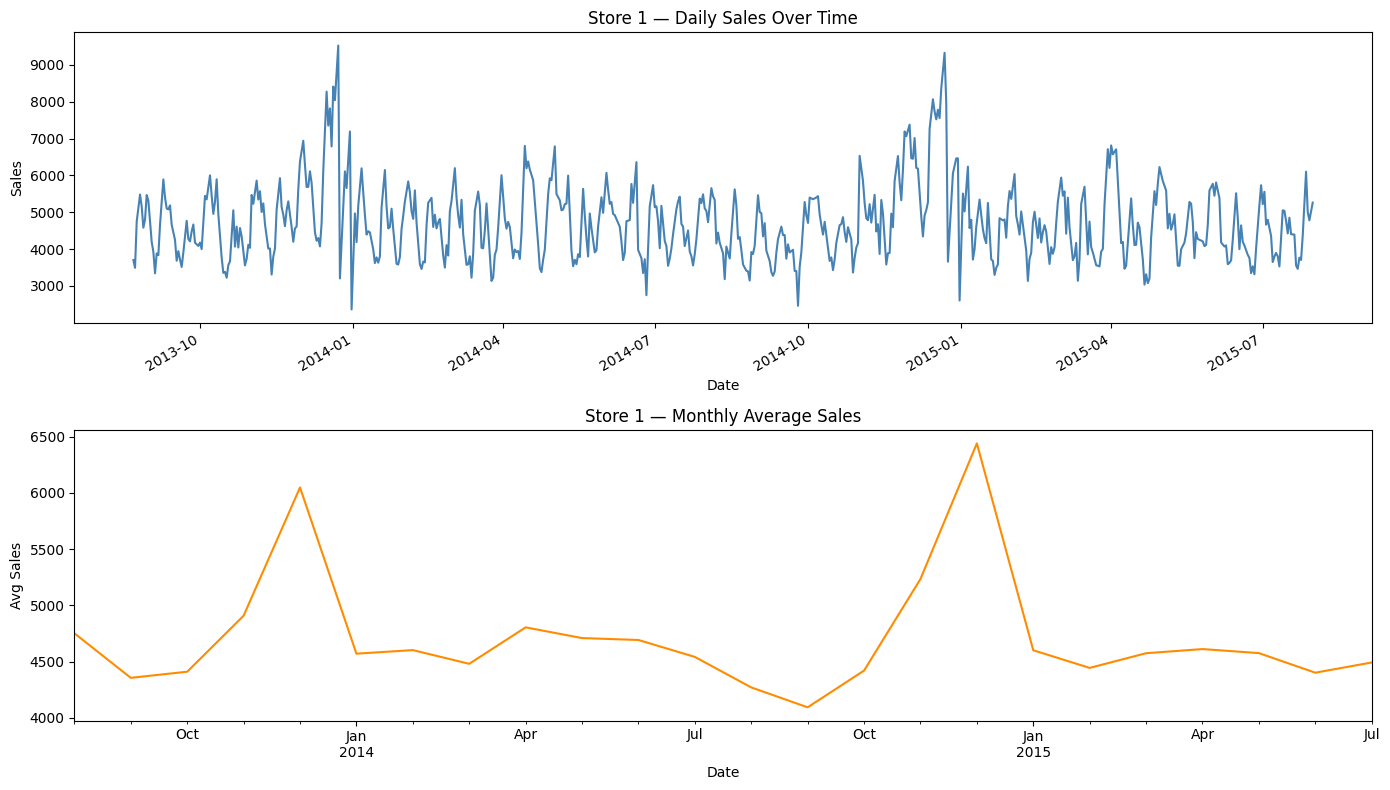

In [4]:
store_df = df[(df['Store'] == 1) & (df['Open'] == 1)].copy()
store_df = store_df.sort_values('Date').set_index('Date')

print('Store 1 records:', len(store_df))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

store_df['Sales'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Store 1 — Daily Sales Over Time')
axes[0].set_ylabel('Sales')

store_df['Sales'].resample('M').mean().plot(ax=axes[1], color='darkorange')
axes[1].set_title('Store 1 — Monthly Average Sales')
axes[1].set_ylabel('Avg Sales')

plt.tight_layout()
plt.savefig('sales_eda.png', dpi=150)
plt.show()

## 3. Stationarity Check — ADF Test

ADF Statistic: -4.664463996029173
p-value: 9.808499117451615e-05
Is stationary: True


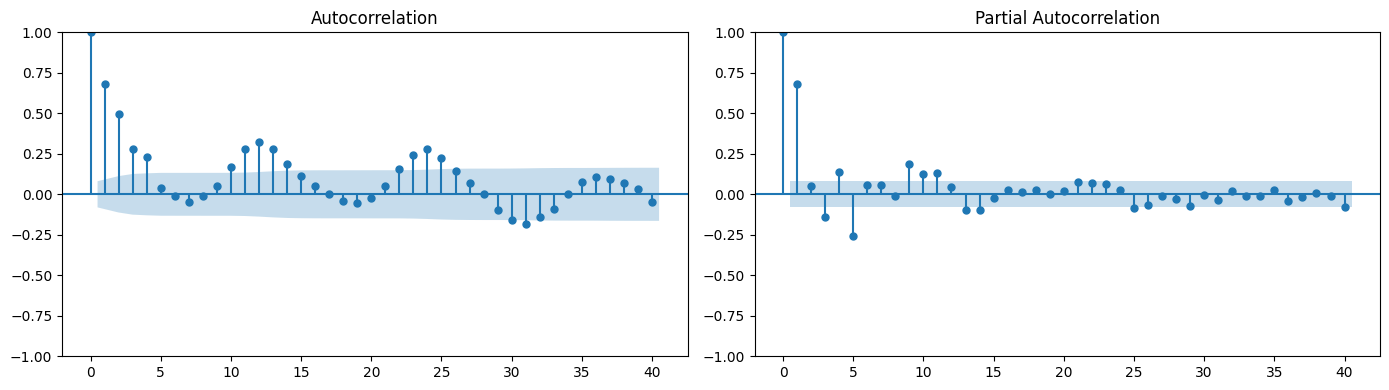

In [5]:
series = store_df['Sales']

result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Is stationary:', result[1] < 0.05)

# Plot ACF and PACF to identify ARIMA parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=40, ax=axes[0])
plot_pacf(series, lags=40, ax=axes[1])
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

## 4. Train/Test Split

In [6]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

print(f'Training samples: {len(train)}')
print(f'Test samples:     {len(test)}')

Training samples: 470
Test samples:     118


## 5. Model 1 — ARIMA

In [7]:
arima_model = ARIMA(train, order=(5, 1, 2))
arima_result = arima_model.fit()

arima_preds = arima_result.forecast(steps=len(test))

arima_mae  = mean_absolute_error(test, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test, arima_preds))

print('=== ARIMA(5,1,2) ===')
print(f'MAE:  {arima_mae:.2f}')
print(f'RMSE: {arima_rmse:.2f}')

=== ARIMA(5,1,2) ===
MAE:  703.99
RMSE: 855.27


## 6. Model 2 — Facebook Prophet

In [8]:
prophet_df = store_df[['Sales']].reset_index()
prophet_df.columns = ['ds', 'y']

prophet_train = prophet_df.iloc[:train_size]
prophet_test  = prophet_df.iloc[train_size:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(prophet_test))
forecast = prophet_model.predict(future)

prophet_preds = forecast['yhat'].iloc[train_size:].values

prophet_mae  = mean_absolute_error(prophet_test['y'], prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_preds))

print('=== Facebook Prophet ===')
print(f'MAE:  {prophet_mae:.2f}')
print(f'RMSE: {prophet_rmse:.2f}')

=== Facebook Prophet ===
MAE:  753.47
RMSE: 971.72


## 7. Forecast Comparison Plot

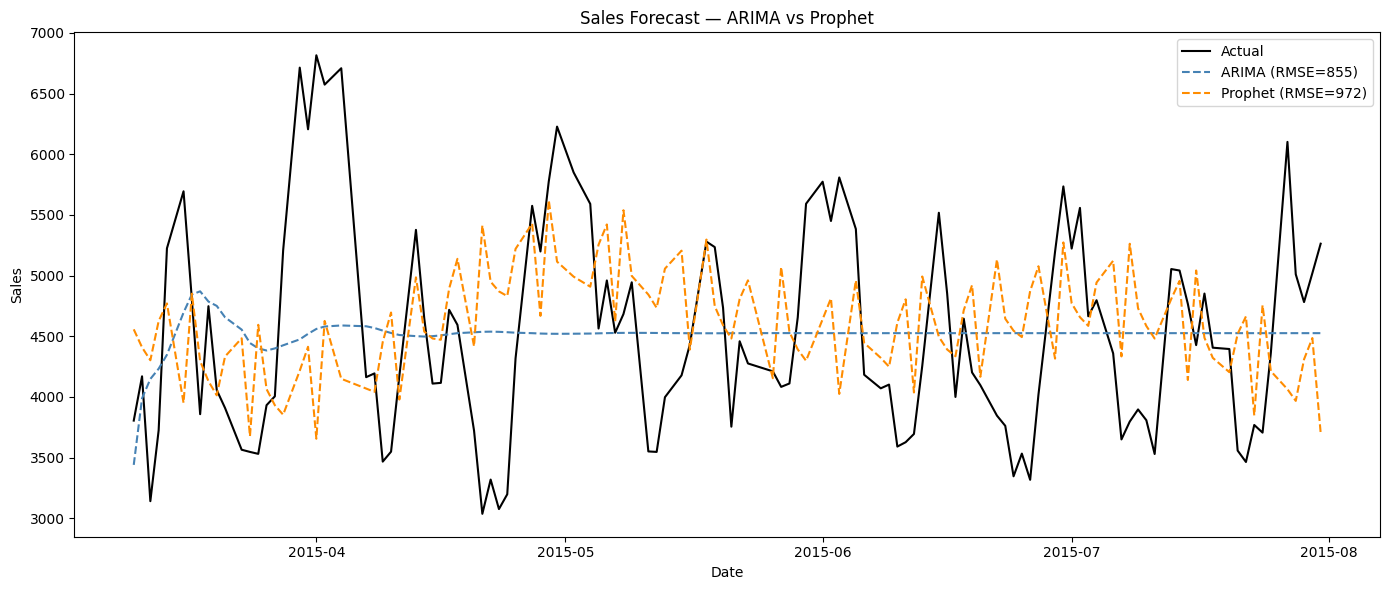

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, label='Actual', color='black', linewidth=1.5)
plt.plot(test.index, arima_preds, label=f'ARIMA (RMSE={arima_rmse:.0f})', color='steelblue', linestyle='--')
plt.plot(test.index, prophet_preds, label=f'Prophet (RMSE={prophet_rmse:.0f})', color='darkorange', linestyle='--')
plt.title('Sales Forecast — ARIMA vs Prophet')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

## 8. Prophet Components — Seasonality Breakdown

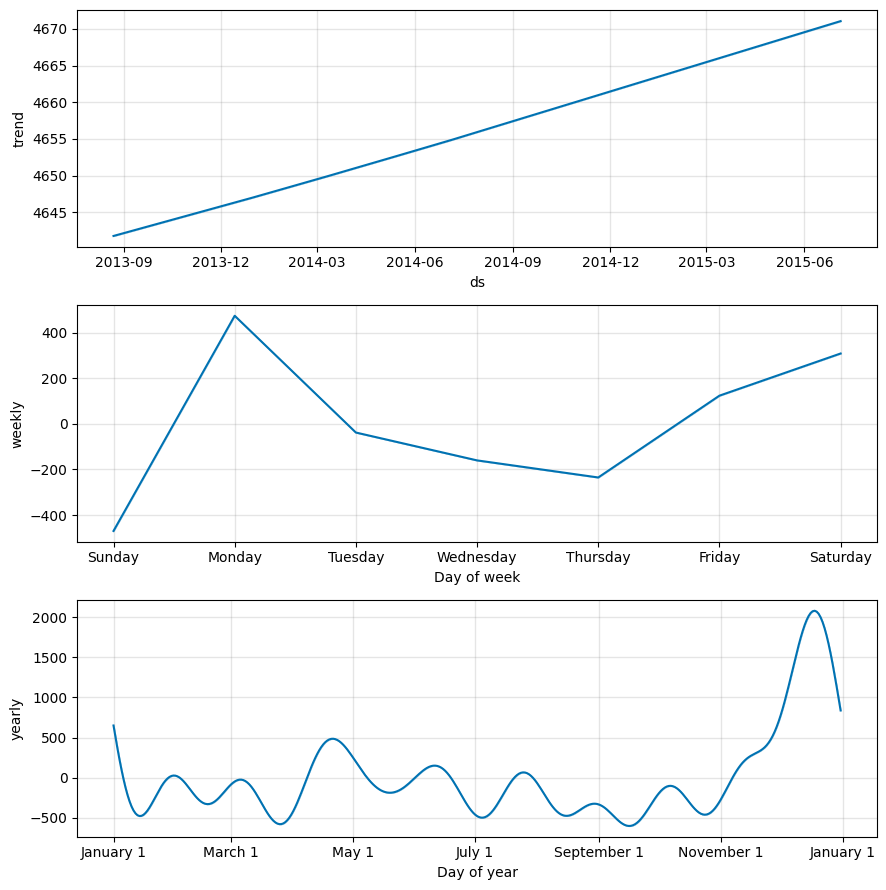

In [10]:
fig = prophet_model.plot_components(forecast)
plt.savefig('prophet_components.png', dpi=150)
plt.show()

## 9. Results Summary

| Model | MAE | RMSE |
|---|---|---|
| ARIMA(5,1,2) | 703.99 | 855.27 |
| Facebook Prophet | 753.47 | 971.72|



**Key findings:**
- Prophet captures weekly and yearly seasonality automatically
- ARIMA requires manual stationarity checks and parameter tuning
- For retail sales with strong seasonal patterns, Prophet generally outperforms ARIMA
- RMSE and MAE tradeoff: RMSE penalises large errors more heavily, important for demand planning